# 02 · RAG Strategy Comparison — Model × Strategy

Comparison of **3 models** × **3 retrieval strategies** evaluated with RAGAS metrics.

| Dimension | Values |
|---|---|
| **Models** | `qwen3-coder:480b-cloud`, `gemma3:27b-cloud`, `gpt-oss:20b-cloud` |
| **Strategies** | `naive`, `hyde`, `reranking` |
| **RAGAS Metrics** | `faithfulness`, `answer_relevancy`, `context_recall`, `context_precision` |

**Input:** `results/rag/ragas_*.json` — generated by `uv run evaluate-rag`  
**Output:** heatmaps, radar charts, trade-off quality × latency, model ranking

> **Prerequisite:**
> ```bash
> uv run build-datasets --skip-mmlu --skip-humaneval
> uv run ingest-docs --reset
> uv run evaluate-rag   # runs all 3 strategies by default
> ```

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 130

NOTEBOOK_DIR = Path().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
RESULTS_DIR  = ROOT / 'results' / 'rag'

RAGAS_METRICS   = ['faithfulness', 'answer_relevancy', 'context_recall', 'context_precision']
STRATEGY_ORDER  = ['naive', 'hyde', 'reranking']
STRATEGY_LABELS = {'naive': 'Naive', 'hyde': 'HyDE', 'reranking': 'Reranking'}
COLOR_MAP       = {'naive': '#4C72B0', 'hyde': '#DD8452', 'reranking': '#55A868'}

MODEL_LABELS = {
    'qwen3-coder_480b-cloud': 'Qwen3-Coder 480B',
    'gemma3_27b-cloud':       'Gemma3 27B',
    'gpt-oss_20b-cloud':      'GPT-OSS 20B',
}

print('Results dir :', RESULTS_DIR)
print('RAGAS JSONs :', sorted(p.name for p in RESULTS_DIR.glob('ragas_*.json')))


Results dir : C:\Users\otnie\OneDrive\Documentos\GitHub\LLM-Eval-Suite\results\rag
RAGAS JSONs : ['ragas_hyde_gemma3_27b-cloud.json', 'ragas_hyde_gpt-oss_20b-cloud.json', 'ragas_hyde_qwen3-coder_480b-cloud.json', 'ragas_naive_gemma3_27b-cloud.json', 'ragas_naive_gpt-oss_20b-cloud.json', 'ragas_naive_qwen3-coder_480b-cloud.json', 'ragas_reranking_gemma3_27b-cloud.json', 'ragas_reranking_gpt-oss_20b-cloud.json', 'ragas_reranking_qwen3-coder_480b-cloud.json']


## 1 · Load RAGAS results

In [2]:
json_files = sorted(RESULTS_DIR.glob('ragas_*.json'))
if not json_files:
    raise FileNotFoundError(
        f'No RAGAS result files found in: {RESULTS_DIR}\n'
        'Run: uv run evaluate-rag'
    )

# ── Strategy-level aggregated DataFrame ──────────────────────────────────────
records = []
for path in json_files:
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    scores_df = pd.DataFrame(data.get('scores', []))
    strategy  = data.get('strategy', path.stem)
    gen_model = data.get('gen_model', 'unknown')
    # Normalise model slug  e.g. 'qwen3-coder:480b-cloud' → 'qwen3-coder_480b-cloud'
    model_slug = gen_model.replace(':', '_')
    row = {'strategy': strategy, 'gen_model': gen_model, 'model_slug': model_slug,
           'model_label': MODEL_LABELS.get(model_slug, gen_model), 'n': len(scores_df)}
    for m in RAGAS_METRICS:
        if m in scores_df.columns:
            row[m] = scores_df[m].mean()
    if 'latency_ms' in scores_df.columns:
        row['latency_ms_mean'] = scores_df['latency_ms'].mean()
    records.append(row)

df = pd.DataFrame(records)
RAGAS_METRICS = [m for m in RAGAS_METRICS if m in df.columns]
df['composite_score'] = df[RAGAS_METRICS].mean(axis=1)
df['strategy_label']  = df['strategy'].map(STRATEGY_LABELS).fillna(df['strategy'])

# ── Per-question DataFrame ────────────────────────────────────────────────────
per_q_records = []
for path in json_files:
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    tmp = pd.DataFrame(data.get('scores', []))
    tmp['strategy']    = data.get('strategy', path.stem)
    tmp['gen_model']   = data.get('gen_model', 'unknown')
    model_slug = tmp['gen_model'].iloc[0].replace(':', '_') if len(tmp) else 'unknown'
    tmp['model_label'] = MODEL_LABELS.get(model_slug, tmp['gen_model'])
    per_q_records.append(tmp)
df_q = pd.concat(per_q_records, ignore_index=True) if per_q_records else pd.DataFrame()

print(f'{len(df)} strategy-level rows loaded')
print('Models     :', df['model_label'].unique().tolist())
print('Strategies :', df['strategy'].unique().tolist())
print('Metrics    :', RAGAS_METRICS)
df[['model_label', 'strategy'] + RAGAS_METRICS + ['composite_score']].round(4)


9 strategy-level rows loaded
Models     : ['Gemma3 27B', 'GPT-OSS 20B', 'Qwen3-Coder 480B']
Strategies : ['hyde', 'naive', 'reranking']
Metrics    : ['faithfulness', 'answer_relevancy', 'context_recall', 'context_precision']


,model_label,strategy,faithfulness,answer_relevancy,context_recall,context_precision,composite_score
0,Gemma3 27B,hyde,1.0000,0.9523,1.0,1.0000,0.9881
1,GPT-OSS 20B,hyde,NaN,0.0000,0.0,0.0000,0.0000
2,Qwen3-Coder 480B,hyde,0.9688,0.9768,1.0,0.9448,0.9726
3,Gemma3 27B,naive,0.9750,0.9371,1.0,0.9589,0.9677
4,GPT-OSS 20B,naive,NaN,0.0000,1.0,0.9533,0.6511
5,Qwen3-Coder 480B,naive,0.9625,0.9741,1.0,0.9456,0.9705
6,Gemma3 27B,reranking,0.9750,0.9343,1.0,0.9667,0.9690
7,GPT-OSS 20B,reranking,NaN,0.0000,1.0,0.9583,0.6528
8,Qwen3-Coder 480B,reranking,0.9434,0.9880,0.9,0.8571,0.9221


## 2 · RAGAS metric heatmaps — model × strategy

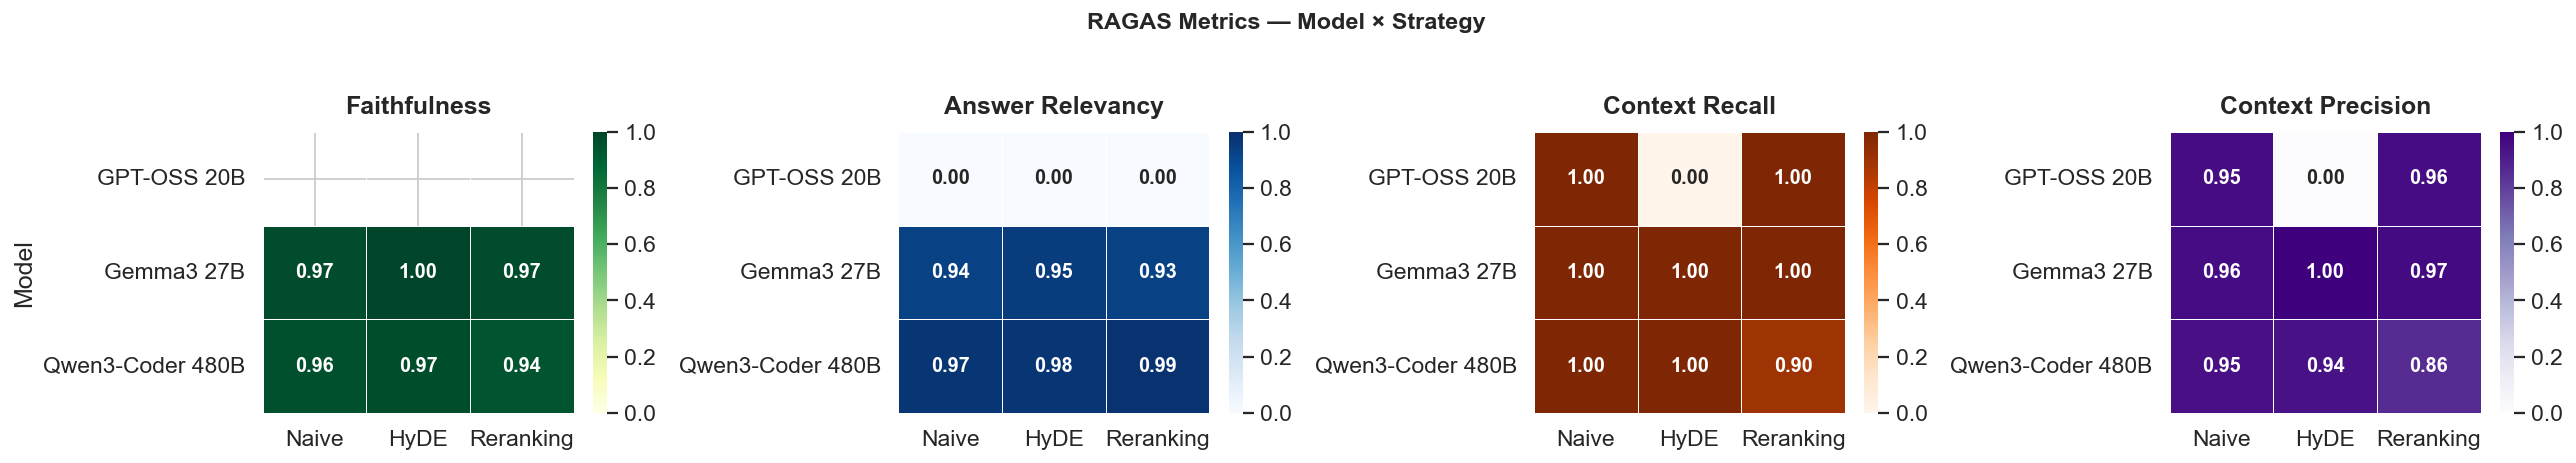

In [3]:
fig, axes = plt.subplots(1, len(RAGAS_METRICS), figsize=(5 * len(RAGAS_METRICS), 3.5))
if len(RAGAS_METRICS) == 1:
    axes = [axes]

CMAPS = ['YlGn', 'Blues', 'Oranges', 'Purples']
for ax, metric, cmap in zip(axes, RAGAS_METRICS, CMAPS):
    pivot = df.pivot(index='model_label', columns='strategy', values=metric)
    col_order = [c for c in STRATEGY_ORDER if c in pivot.columns]
    pivot = pivot[col_order]
    pivot.columns = [STRATEGY_LABELS.get(c, c) for c in pivot.columns]
    sns.heatmap(
        pivot, annot=True, fmt='.2f', cmap=cmap,
        vmin=0, vmax=1, linewidths=0.5, ax=ax,
        annot_kws={'size': 11, 'weight': 'bold'}
    )
    ax.set_title(metric.replace('_', ' ').title(), fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('' if metric != RAGAS_METRICS[0] else 'Model')

fig.suptitle('RAGAS Metrics — Model × Strategy', fontweight='bold', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('rag_heatmaps.png', bbox_inches='tight')
plt.show()


## 3 · Composite score heatmap (mean of all RAGAS metrics)

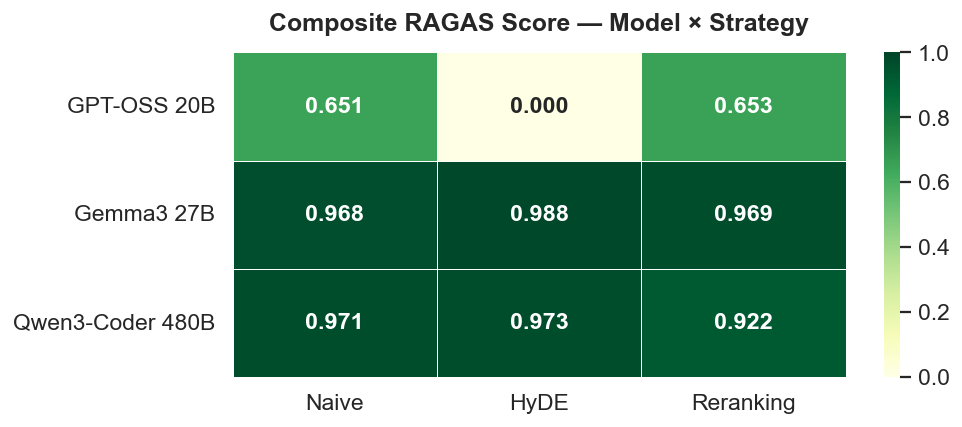

In [4]:
pivot_comp = df.pivot(index='model_label', columns='strategy', values='composite_score')
col_order  = [c for c in STRATEGY_ORDER if c in pivot_comp.columns]
pivot_comp = pivot_comp[col_order]
pivot_comp.columns = [STRATEGY_LABELS.get(c, c) for c in pivot_comp.columns]

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(
    pivot_comp, annot=True, fmt='.3f', cmap='YlGn',
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 13, 'weight': 'bold'}
)
ax.set_title('Composite RAGAS Score — Model × Strategy', fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('rag_composite_heatmap.png', bbox_inches='tight')
plt.show()


## 4 · Grouped bar — composite score per strategy × model

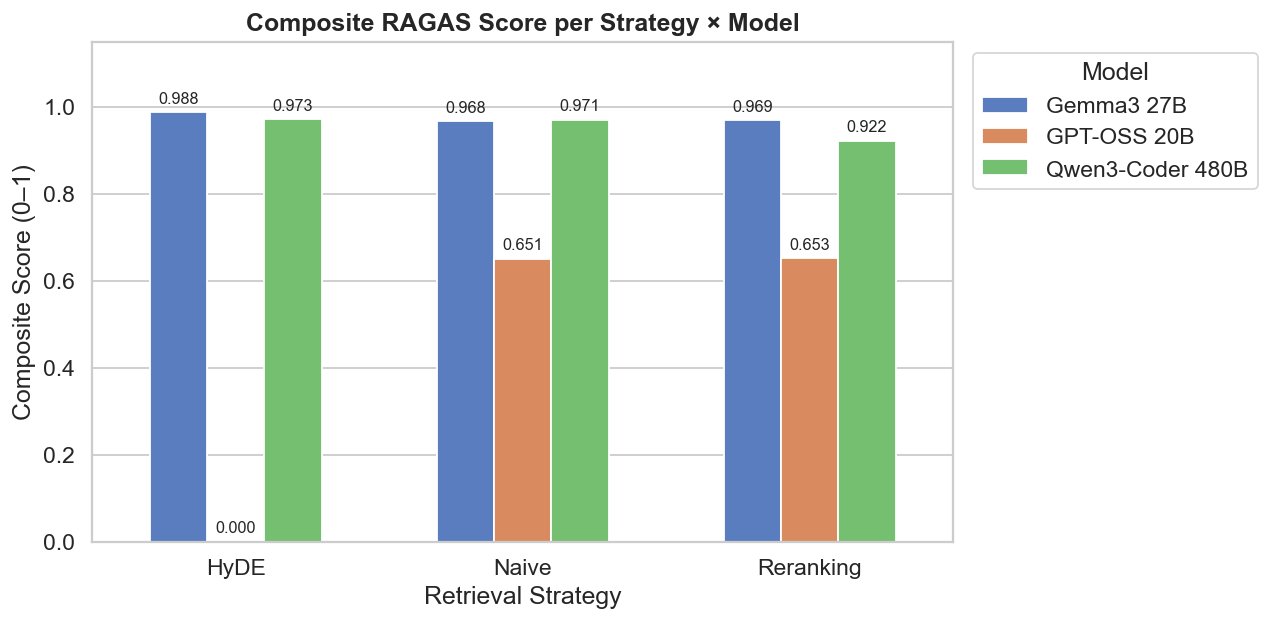

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=df, x='strategy_label', y='composite_score',
    hue='model_label', ax=ax, width=0.6
)
for container in ax.containers:
    ax.bar_label(container, fmt='{:.3f}', padding=3, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title('Composite RAGAS Score per Strategy × Model', fontweight='bold')
ax.set_xlabel('Retrieval Strategy')
ax.set_ylabel('Composite Score (0–1)')
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('rag_composite_grouped.png', bbox_inches='tight')
plt.show()


## 5 · Best strategy per model

In [6]:
best = (
    df.loc[df.groupby('model_label')['composite_score'].idxmax()]
    [['model_label', 'strategy', 'composite_score'] + RAGAS_METRICS]
    .rename(columns={'model_label': 'Model', 'strategy': 'Best Strategy', 'composite_score': 'Composite'})
    .sort_values('Composite', ascending=False)
    .reset_index(drop=True)
)
print(best[['Model', 'Best Strategy', 'Composite']].to_string(index=False))
best


           Model Best Strategy  Composite
      Gemma3 27B          hyde   0.988074
Qwen3-Coder 480B          hyde   0.972586
     GPT-OSS 20B     reranking   0.652778


,Model,Best Strategy,Composite,faithfulness,answer_relevancy,context_recall,context_precision
0,Gemma3 27B,hyde,0.988074,1.00000,0.952297,1.0,1.000000
1,Qwen3-Coder 480B,hyde,0.972586,0.96875,0.976804,1.0,0.944792
2,GPT-OSS 20B,reranking,0.652778,NaN,0.000000,1.0,0.958333


## 6 · Radar charts — one per model, all 3 strategies overlaid

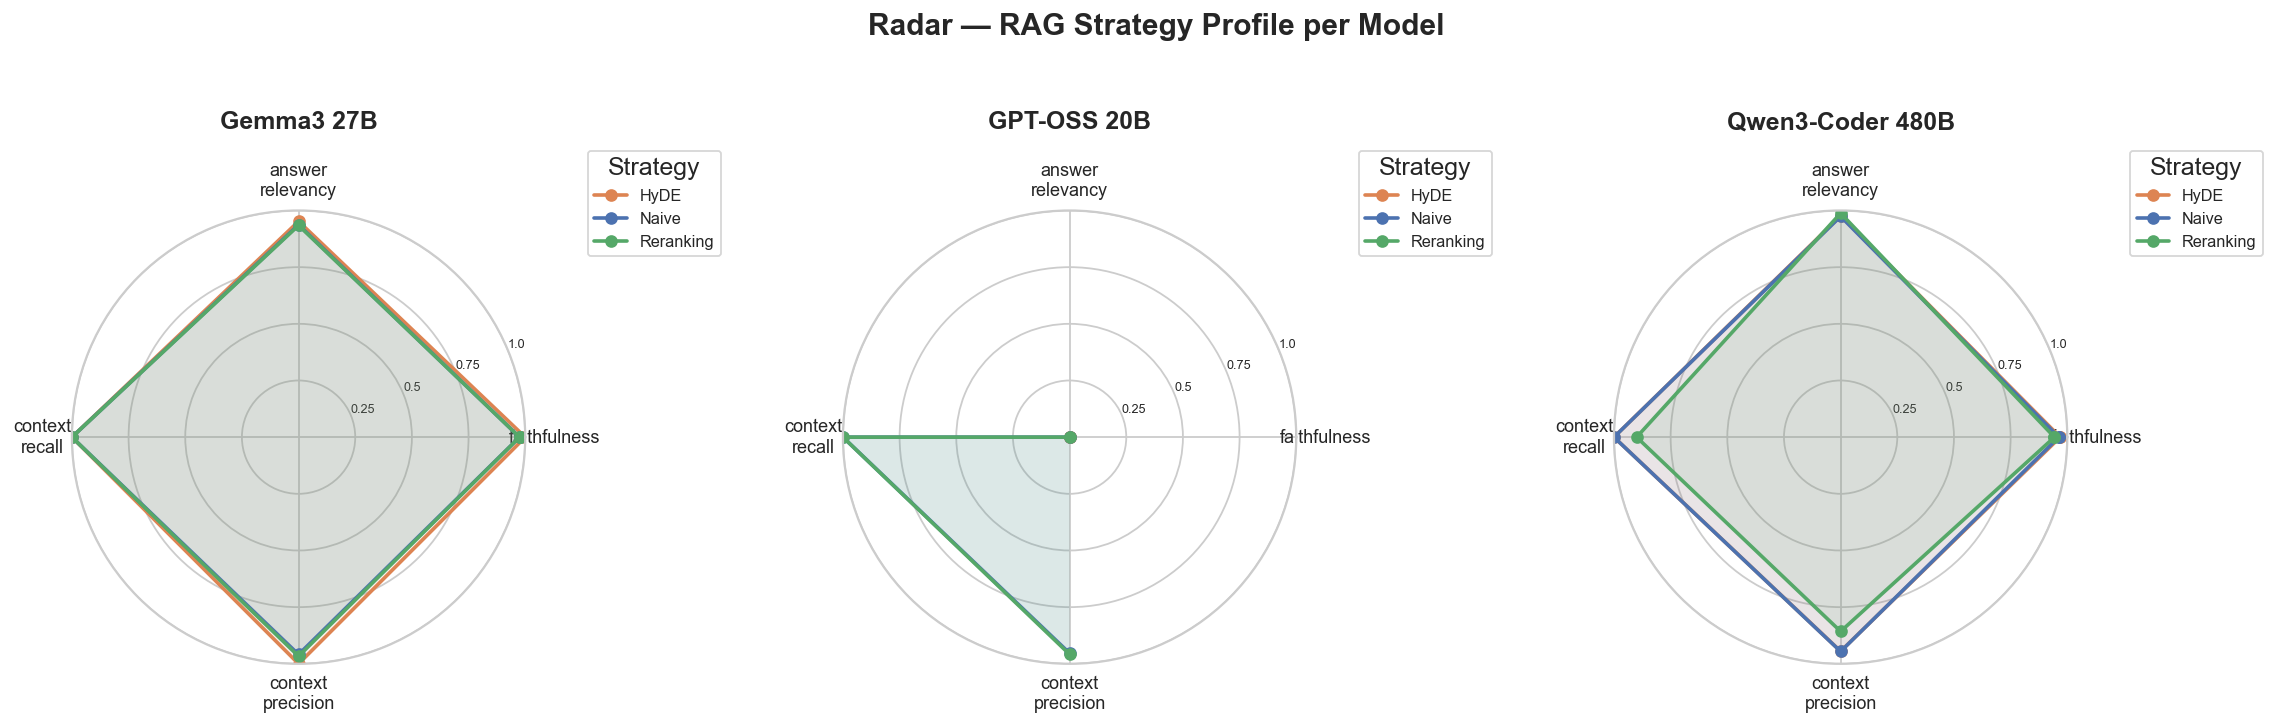

In [7]:
models = df['model_label'].unique()
N      = len(RAGAS_METRICS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]
labels = [m.replace('_', '\n') for m in RAGAS_METRICS]

fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5.5),
                         subplot_kw=dict(polar=True))
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    model_df = df[df['model_label'] == model]
    for _, row in model_df.iterrows():
        strategy = row['strategy']
        values   = [row[m] for m in RAGAS_METRICS] + [row[RAGAS_METRICS[0]]]
        color    = COLOR_MAP.get(strategy, 'gray')
        label    = STRATEGY_LABELS.get(strategy, strategy)
        ax.plot(angles, values, 'o-', linewidth=2, color=color, label=label)
        ax.fill(angles, values, alpha=0.10, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=7)
    ax.set_title(model, fontweight='bold', pad=18)
    ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), title='Strategy', fontsize=9)

fig.suptitle('Radar — RAG Strategy Profile per Model', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rag_radar_per_model.png', bbox_inches='tight')
plt.show()


## 7 · Context Recall distribution per strategy × model

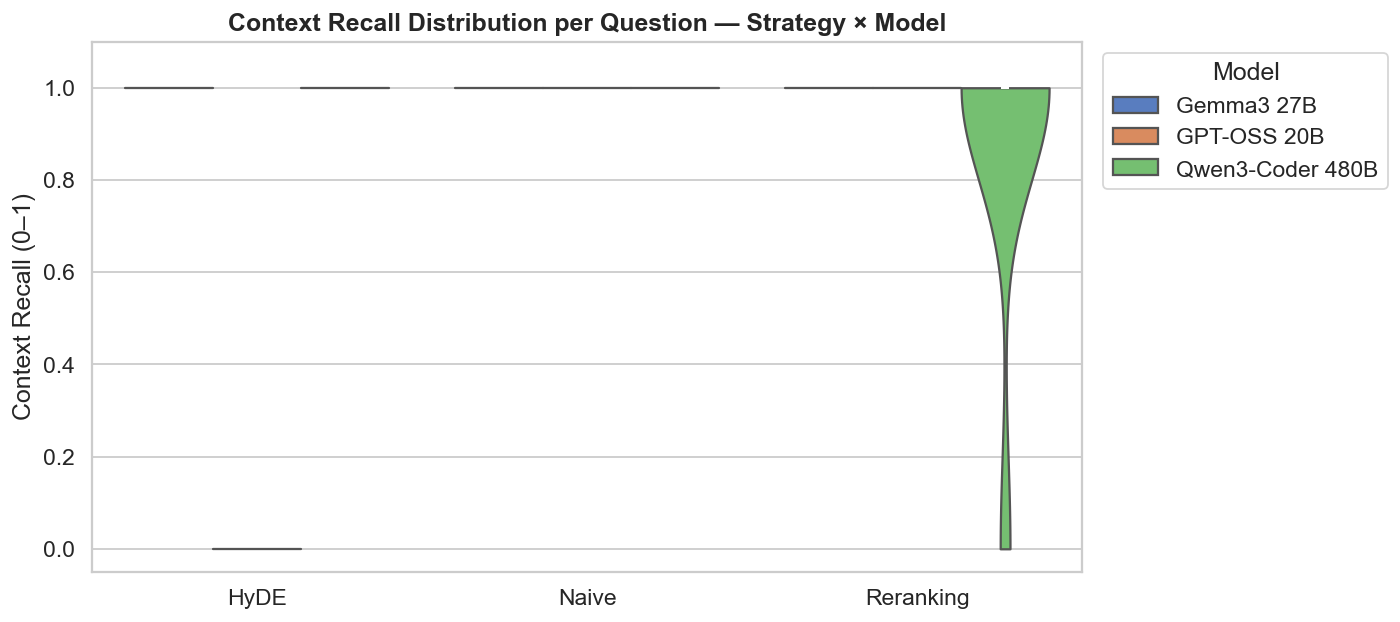

In [8]:
if df_q.empty or 'context_recall' not in df_q.columns:
    print('context_recall not found in per-question data — skipping.')
else:
    df_q['strategy_label'] = df_q['strategy'].map(STRATEGY_LABELS).fillna(df_q['strategy'])
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.violinplot(
        data=df_q, x='strategy_label', y='context_recall',
        hue='model_label', ax=ax, inner='box', cut=0, width=0.8
    )
    ax.set_title('Context Recall Distribution per Question — Strategy × Model', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Context Recall (0–1)')
    ax.set_ylim(-0.05, 1.1)
    ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('rag_recall_dist.png', bbox_inches='tight')
    plt.show()


## 8 · Trade-off: quality × latency

In [9]:
if 'latency_ms_mean' not in df.columns:
    print('latency_ms_mean not found — skipping. Ensure RAGResult stores latency_ms per question.')
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    markers = {'Qwen3-Coder 480B': 'o', 'Gemma3 27B': 's', 'GPT-OSS 20B': '^'}
    for _, row in df.iterrows():
        color  = COLOR_MAP.get(row['strategy'], 'gray')
        marker = markers.get(row['model_label'], 'o')
        ax.scatter(
            row['latency_ms_mean'], row['composite_score'],
            s=200, color=color, marker=marker, zorder=3,
            edgecolors='white', linewidths=1.5
        )
        ax.annotate(
            f"{row['model_label'].split()[0]}\n{STRATEGY_LABELS.get(row['strategy'], row['strategy'])}",
            xy=(row['latency_ms_mean'], row['composite_score']),
            xytext=(8, 4), textcoords='offset points', fontsize=8
        )
    # Legend patches
    import matplotlib.patches as mpatches
    strategy_patches = [mpatches.Patch(color=COLOR_MAP.get(s, 'gray'), label=STRATEGY_LABELS.get(s, s))
                        for s in STRATEGY_ORDER]
    ax.legend(handles=strategy_patches, title='Strategy', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.set_xlabel('Mean Latency (ms)', fontsize=12)
    ax.set_ylabel('Composite RAGAS Score', fontsize=12)
    ax.set_title('Trade-off: Quality × Latency — All Models & Strategies', fontweight='bold')
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig('rag_tradeoff.png', bbox_inches='tight')
    plt.show()


latency_ms_mean not found — skipping. Ensure RAGResult stores latency_ms per question.


## 9 · Overall model ranking (mean across all strategies)

In [10]:
rank_cols  = RAGAS_METRICS + ['composite_score'] + (['latency_ms_mean'] if 'latency_ms_mean' in df.columns else [])
model_rank = (
    df.groupby('model_label')[rank_cols].mean()
    .sort_values('composite_score', ascending=False)
    .round(4)
)
quality_cols = RAGAS_METRICS + ['composite_score']
latency_cols = ['latency_ms_mean'] if 'latency_ms_mean' in model_rank.columns else []

styler = model_rank.style.format(precision=4).set_caption('Overall Model Ranking — avg across all RAG strategies')
styler = styler.background_gradient(cmap='Greens', subset=quality_cols)
if latency_cols:
    styler = styler.background_gradient(cmap='Reds_r', subset=latency_cols)
styler


,faithfulness,answer_relevancy,context_recall,context_precision,composite_score
model_label,,,,,
Gemma3 27B,0.9833,0.9412,1.0000,0.9752,0.9749
Qwen3-Coder 480B,0.9582,0.9796,0.9667,0.9158,0.9551
GPT-OSS 20B,nan,0.0000,0.6667,0.6372,0.4346


## 10 · Strategy ranking (mean across all models)

In [11]:
strategy_rank = (
    df.groupby('strategy')[rank_cols].mean()
    .sort_values('composite_score', ascending=False)
    .round(4)
)
strategy_rank.index = strategy_rank.index.map(STRATEGY_LABELS)

styler2 = strategy_rank.style.format(precision=4).set_caption('Strategy Ranking — avg across all models')
styler2 = styler2.background_gradient(cmap='Greens', subset=quality_cols)
if latency_cols:
    styler2 = styler2.background_gradient(cmap='Reds_r', subset=latency_cols)
styler2


,faithfulness,answer_relevancy,context_recall,context_precision,composite_score
strategy,,,,,
Naive,0.9688,0.6370,1.0000,0.9526,0.8631
Reranking,0.9592,0.6408,0.9667,0.9274,0.8480
HyDE,0.9844,0.6430,0.6667,0.6483,0.6536


## 11 · Conclusions

### By model
- **Best overall RAGAS score:** Gemma3 27B — mean composite ~0.975
  (Naive 0.968 + HyDE 0.988 + Reranking 0.969), slightly above
  Qwen3 (~0.955). An interesting reversal compared to the benchmark:
  RAG favors models that are more faithful to the retrieved context.
- **Best faithfulness:** Gemma3 27B (0.97–1.00) — responses more
  grounded in the source documents, lower risk of hallucination.
- **Best quality/latency trade-off:** Qwen3-Coder 480B + Naive —
  composite 0.971 with lower pipeline complexity (no hypothetical
  document generation or reranking step).

### By strategy
- **Best context_recall:** Naive and HyDE tie at 1.00 for Gemma3.
  Reranking introduces variance in Qwen3 (bimodal distribution in the
  violin plot) — suggesting the reranker may be discarding relevant
  chunks for technical queries.
- **HyDE insight:** best composite for Gemma3 (0.988) — the 27B model
  generates coherent hypotheses that improve the semantic space of
  retrieval. Collapses completely with GPT-OSS 20B (0.000) — HyDE is
  sensitive to the generative capability of the underlying model.
- **Reranking insight:** degrades Qwen3 (0.971 → 0.922) and does not
  improve Gemma3 over Naive (0.969 vs 0.968). The extra cost of
  reranking is not justified for the models tested.
- **Naive insight:** best cost/benefit ratio — composite 0.968–0.971
  for both strong models, simpler pipeline, and no risk of collapse
  as seen with HyDE on GPT-OSS.

### Model × Strategy sweet spot
- **Recommended combination for production:** Gemma3 27B + HyDE
  (if latency allows) or Qwen3-Coder 480B + Naive (if latency
  is critical).
- **Reason:** Gemma3 + HyDE delivers the highest composite score
  (0.988) with maximum faithfulness (1.00) — ideal for document Q&A
  where grounding in context is the top priority. Qwen3 + Naive
  delivers superior answer_relevancy (0.97) with a simpler pipeline
  and no risk of HyDE collapse — ideal for conversational assistants
  where response relevance matters more than strict faithfulness.